In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [12]:
from IPython.display import Math, display
show = lambda func: display(Math(func.__str__()))

In [13]:
class WingBox:
    def __init__(self, thickness, chord, material):
        self.t, self.b, self.h = thickness, base, height
        self.mat = material

In [14]:
def readAirfoil(file='airfoil.dat'):
    with open(file, 'r') as f:
        data = f.read().split('\n\n')
    shape = [[], []]
    for d in range(2):
        shape[d].append([[float(n.strip(' ')) for n in thing.split('  ') if n] for thing in data[d].split('\n') if thing])
    df = pd.DataFrame({'xb': [lis[0] for lis in shape[0][0]], 'top': [lis[1] for lis in shape[0][0]], 'bot': [lis[1] for lis in shape[1][0]]})
    df.set_index('xb', inplace=True)
    return df
readAirfoil().to_csv('aerofoil.csv')

<AxesSubplot:xlabel='xb'>

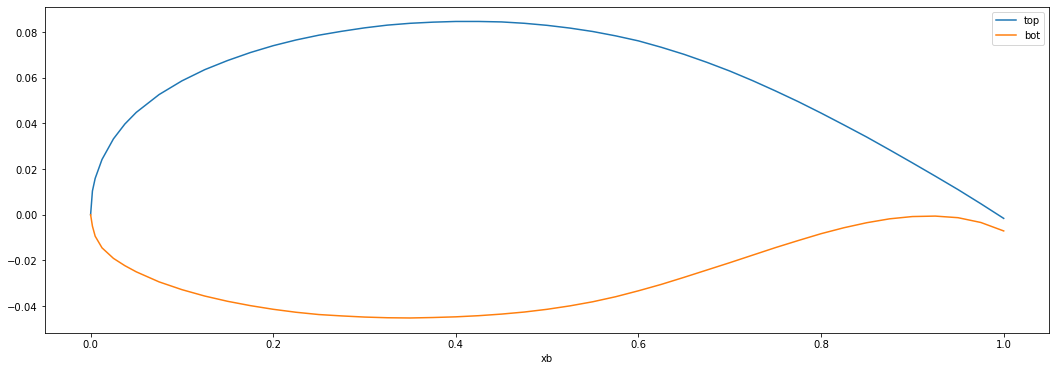

In [15]:
df = pd.read_csv('aerofoil.csv', index_col='xb')
df.plot(figsize=(18, 6))

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
poly = PolynomialFeatures(degree=len(df))
lin.fit(poly.fit_transform(df.index.to_numpy().reshape(-1, 1)), df[['top', 'bot']].values)
df[['ptop', 'pbot']] = lin.predict(poly.transform(df.index.to_numpy().reshape(-1, 1)))

<AxesSubplot:xlabel='xb'>

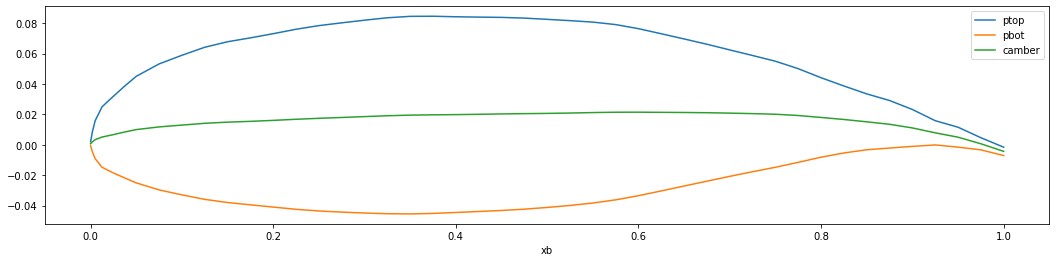

In [17]:
from MathFunctions.Polynomial import Polynomial
top, bot = [Polynomial([lin.intercept_[p] + lin.coef_[p][0]] + list(lin.coef_[p][1:]), symbol='\\left(\\frac{x}{c}\\right)') for p in range(2)]
camber = (top + bot) / 2
camber.s = bot.s
df['camber'] = camber(df.index)
df.plot(figsize=(18, 4), y=['ptop', 'pbot', 'camber'])

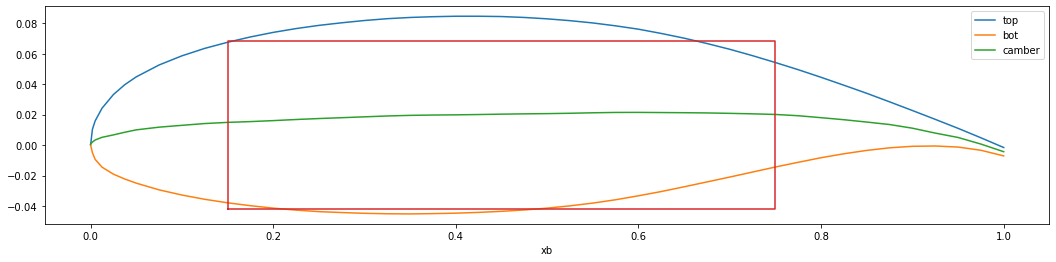

In [18]:
top.max(0.15, 0.4), top(0.15)
tmax, bmin, t15, b15 =  top.max(0.16, 0.4), bot.min(0.15, 0.4), top(0.15), bot(0.15)
tsk, bsk = (tmax + t15) / 2, (bmin + b15) / 2
coord = list(np.array([[0.15, bsk], [0.75, bsk], [0.75, tsk], [0.15, tsk], [0.15, bsk]]).T)
df.plot(figsize=(18, 4), y=['top', 'bot', 'camber'])
plt.plot(*coord)

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from numpy import linspace

dev = False # If you aren't Kaizad this should be disabled.

def PlotContour(xp, y, z, xtit, ytit, title, x):
    fig = go.Figure(data=go.Heatmap(
        x=xp,
        y=y,
        z=z,
        connectgaps=False,
        colorscale='Picnic',
        zsmooth='best'
    ), layout=go.Layout(
        xaxis=dict(title=xtit, autorange='reversed'),
        yaxis=dict(title=ytit),
        title=f'Cross Sectional {title} Stress Distribution at {x = } m'
    ))
    if dev:
        fig.write_html(f'/var/www/html/{title.lower()}.html')
    return fig

def NormalStressPlot(oxx, x, Ch, Ca, shape, tsk, **others):
    zi = list(linspace(Ch - Ca, Ch, 1200, dtype='float'))
    yi = list(linspace(-Ch, Ch, 600, dtype='float'))
    o_zy = [[None if abs(y_i) > shape(z_i) else oxx(z_i, y_i)(x)*1e-6 for z_i in zi] for y_i in yi]
    return PlotContour(zi, yi, o_zy,
        'Chordwise Distribution [m]',
        'Vertical Distribution [m]',
        'Normal', x)

def ShearStressPlot(oxx, x, Ch, Ca, shape, tsk, tsp, **others):
    zi = list(linspace(Ch - Ca, Ch, 1800, dtype='float'))
    yi = list(linspace(-Ch, Ch, 1200, dtype='float'))
    o_zy = [[None if abs(y_i) > shape(z_i) or (abs(y_i) < shape(z_i) - tsk and not -tsp < z_i < tsp) \
        else oxx(z_i, y_i)(x)*1e-6 for z_i in zi] for y_i in yi]
    return PlotContour(zi, yi, o_zy,
        'Chordwise Distribution [m]',
        'Vertical Distribution [m]',
        'Shear', x)

def InternalLoading(x0, x1, **Loads):
    titles = [k + f' [kN{"" if k[0].upper() == "S" else "m"}]' for k in Loads]
    fig = make_subplots(rows=len(list(Loads.keys())), cols=1, shared_xaxes=True, vertical_spacing=0.01)
    xs = linspace(x0, x1, 5000)
    for i, (li, load) in enumerate(zip(Loads.keys(), Loads.values())):
        fig.append_trace(go.Scatter(
            x=xs,
            y=[load(xi)*1e-3 for xi in xs],
            name=li,
        ), row=i+1, col=1)
        fig.update_yaxes(title_text=titles[i], row=i+1, col=1)

    fig.update_xaxes(title_text="Spanwise Position [meters]", row=len(Loads.keys()), col=1)
    fig.update_layout(
        title="Internal Load (NVM) Diagram",
        template="plotly_dark")

    if dev:
        fig.write_html('/var/www/html/nvmnum.html')
    return fig

def Deflections(x0, x1, pi, **defs):
    titles = [k + f' [{"millimeters" if k[0].lower() in ["w", "v"] else "degrees"}]' for k in defs]
    fig = make_subplots(rows=len(list(defs.keys())), cols=1, shared_xaxes=True, vertical_spacing=0.01)
    xs = linspace(x0, x1, 5000)
    for i, (li, load) in enumerate(zip(defs.keys(), defs.values())):
        fig.append_trace(go.Scatter(
            x=xs,
            y=[load(xi)*(180 / pi if 'degrees' in titles[i] else 1e3) for xi in xs],
            name=li,
        ), row=i+1, col=1)
        fig.update_yaxes(title_text=titles[i], row=i+1, col=1)

    fig.update_xaxes(title_text="Spanwise Position [meters]", row=len(defs.keys()), col=1)
    fig.update_layout(
        title="Deflection Diagram")

    if dev:
        fig.write_html('/var/www/html/deflectionsnum.html')
    return fig


In [41]:
from Analysis import Stringer, WingBox, WingStructure
from Equilibrium import PointLoad, Moment, RunningLoad, EquilibriumEquation

class Engines:
    def __init__(self, number, ThrustHover, ThrustCruise, positions: list[float, int]):
        self.n, self.Thover, self.Tcruise = number, ThrustHover, ThrustCruise
        self.pos = positions

class WingLoads:
    def __init__(self, **kwargs):
        self.b, self.l, self.cr, self.tsk, self.tsp, self.toc, self.nStrT, self.nStrB, self.StrA, \
        self.engines, self.xac, self.mac = \
            [kwargs.get(k, None) for k in \
                ['span', 'taper', 'rootchord', 'thicknessOfSkin', 'thicknessOfSpar', 'toc', 'nStrT',
                 'nStrB', 'StrA', 'engines', 'xac', 'MAC']]
        self.wing = None

    
    __repr__ = __str__ = lambda self: "Wingloads(" + ', '.join(f"{k}={self.__dict__[k]}" for k in self.__dict__) + ")"

    def createStructure(self):
        box = WingBox(self.tsk, self.tsp, 1, self.toc)
        box.StrPlacement(self.nStrT, self.nStrB, self.StrA)
        self.wing = WingStructure(self.b, self.l, self.cr, box)

    def equilibriumCruise(self, dragDistr, liftDistr):
        wing = self.wing
        Thrusts = [PointLoad([-self.engines.Tcruise, 0, 0], [0, 0, p]) for p in self.engines.pos] # Redefine x, y
        Drag = RunningLoad([dragDistr[1], [0]*len(dragDistr[1])], dragDistr[0], axis=2, poa=(0, 0))
        Lift = RunningLoad([liftDistr[1], [0]*len(liftDistr[1])], liftDistr[0], axis=2, poa=((self.xac-0.15*self.mac), 0))
        


In [40]:
args = dict(span=10, taper=0.4, rootchord=0.5, thicknessOfSkin=1e-3, thicknessOfSpar=1e-2,
            toc=0.17, nStrT=5, nStrB=3, StrA=1e-4, MAC=0.3)

WingLoads(**args).createStructure()